# 💬 LangGraph: Stateful Chatbot with MemorySaver & Thread Isolation

### 📌 Overview
This notebook implements a **Stateful Conversational Chatbot** using LangGraph's persistence layer:
1. **Message Reducer (`add_messages`):** Automatically appends new user prompts and AI responses to conversation history without manual list concatenation.
2. **In-Memory Checkpointer (`MemorySaver`):** Saves the graph state at every execution turn.
3. **Thread-Level Isolation (`thread_id`):** Segregates conversations so different users or chat sessions maintain independent memory states.
4. **State Inspection (`get_state`):** Reads the current state snapshot directly from the checkpointer.

---

### 🗺️ Graph Topology

```text
┌─────────┐       ┌─────────────┐       ┌───────┐
│  START  │ ────► │  chat_node  │ ────► │  END  │
└─────────┘       └─────────────┘       └───────┘
                         ▲
                         │ [MemorySaver Checkpointer]
                         ▼
                 (Thread-Level History)
```

*Execution Flow:* `START` ➔ `chat_node` (Invokes LLM with full context) ➔ `END` (State saved to thread)

In [1]:
import os
from typing import Annotated, TypedDict
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages

# Load environment variables
load_dotenv()

# Verify OpenRouter key
if not os.getenv("OPENROUTER_API_KEY"):
    raise ValueError(
        "OPENROUTER_API_KEY is missing. Please add it to your .env file: "
        "OPENROUTER_API_KEY=sk-or-v1-..."
    )

### 2. Initialize LLM via OpenRouter
We use `ChatOpenAI` configured with OpenRouter's `openrouter/free` router and `temperature=0.7` for natural conversational responses.

In [2]:
# OpenRouter configuration with Free Models Router
model = ChatOpenAI(
    model="openrouter/free",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
    temperature=0.7,
)

### 3. Define Graph State Schema with `add_messages`
In LangGraph, chat history is stored under a `messages` key using the built-in **`add_messages` reducer**.

Instead of overwriting previous messages, `add_messages`:
* Appends new `HumanMessage` and `AIMessage` objects to the list.
* Preserves message IDs and metadata.
* Overwrites an existing message only if an incoming message shares the exact same ID (useful for editing or tool-call updates).

In [3]:
class ChatState(TypedDict):
    # Built-in reducer automatically appends message turns
    messages: Annotated[list[BaseMessage], add_messages]

### 4. Define the Chat Node
The node receives the entire conversation history from `state["messages"]`, sends it to the LLM, and returns only the newly generated `AIMessage` delta.

In [4]:
def chat_node(state: ChatState) -> dict:
    """Invokes the model with complete chat history and emits the AI response delta."""
    response = model.invoke(state["messages"])
    # Return delta: add_messages reducer automatically appends this to state
    return {"messages": [response]}

### 5. Build and Compile Graph with a Checkpointer
We initialize an in-memory checkpointer (`MemorySaver`). When compiled with `checkpointer=memory`, the graph automatically stores state snapshots under distinct thread IDs.

In [5]:
# 1. Initialize checkpointer
memory = MemorySaver()

# 2. Build graph
builder = StateGraph(ChatState)
builder.add_node("chat_node", chat_node)
builder.add_edge(START, "chat_node")
builder.add_edge("chat_node", END)

# 3. Compile with checkpointer
chatbot = builder.compile(checkpointer=memory)

### 6. Visualize Graph Topology
Evaluating the compiled `chatbot` object renders the interactive graph.

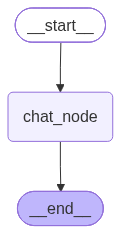

In [6]:
chatbot

### 7. Demonstrate Thread Memory & State Persistence
We demonstrate how the chatbot remembers context across multiple turns within the same `thread_id`.

In [7]:
config_thread_1 = {"configurable": {"thread_id": "session-1"}}

# Turn 1: Introduce user name
print("=== TURN 1 (Thread 1) ===")
input_1 = {"messages": [HumanMessage(content="Hello! My name is Batuhan.")]}
response_1 = chatbot.invoke(input_1, config=config_thread_1)
print(f"AI: {response_1['messages'][-1].content}\n")

# Turn 2: Ask about previous context
print("=== TURN 2 (Thread 1) ===")
input_2 = {"messages": [HumanMessage(content="What is my name?")]}
response_2 = chatbot.invoke(input_2, config=config_thread_1)
print(f"AI: {response_2['messages'][-1].content}\n")

=== TURN 1 (Thread 1) ===
AI: Hello Batuhan! 👋 Nice to meet you! How can I help you today?

=== TURN 2 (Thread 1) ===
AI: Your name is **Batuhan**! 😊

You introduced yourself as Batuhan in your first message, and I'm happy to confirm it. Is there anything else I can help you with today?



### 8. Demonstrate Thread Isolation
To prove that memory is partitioned by thread, we create `session-2`. Because it has a different `thread_id`, the chatbot has no knowledge of the user's name.

In [8]:
config_thread_2 = {"configurable": {"thread_id": "session-2"}}

print("=== NEW SESSION (Thread 2) ===")
isolated_input = {"messages": [HumanMessage(content="What is my name?")]}
isolated_response = chatbot.invoke(isolated_input, config=config_thread_2)
print(f"AI: {isolated_response['messages'][-1].content}")

=== NEW SESSION (Thread 2) ===
AI: User Safety: safe


### 9. Inspect Checkpoint State Snapshots
We can inspect the exact snapshot persisted in memory for `session-1`.

In [9]:
snapshot = chatbot.get_state(config_thread_1)
print(f"Current Thread ID: {snapshot.config['configurable']['thread_id']}")
print(f"Total Messages in Memory: {len(snapshot.values['messages'])}")
print("\nConversation History:")
for msg in snapshot.values["messages"]:
    role = "User" if isinstance(msg, HumanMessage) else "AI"
    print(f"- {role}: {msg.content}")

Current Thread ID: session-1
Total Messages in Memory: 4

Conversation History:
- User: Hello! My name is Batuhan.
- AI: Hello Batuhan! 👋 Nice to meet you! How can I help you today?
- User: What is my name?
- AI: Your name is **Batuhan**! 😊

You introduced yourself as Batuhan in your first message, and I'm happy to confirm it. Is there anything else I can help you with today?


### 10. Interactive CLI Chat Loop
An interactive console loop to test multi-turn conversations in real time. Type `quit`, `exit`, or `bye` to end.

In [11]:
chat_config = {"configurable": {"thread_id": "interactive-cli-session"}}

print("Chatbot initialized! Type 'quit' to exit.\n" + "-" * 50)

while True:
    user_input = input("You: ").strip()
    if not user_input:
        continue

    if user_input.lower() in ["exit", "quit", "bye"]:
        print("Session ended. Goodbye!")
        break

    print(f"You: {user_input}")
    output = chatbot.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=chat_config,
    )
    print(f"AI:  {output['messages'][-1].content}\n")

Chatbot initialized! Type 'quit' to exit.
--------------------------------------------------
You: Can you concisely explain what LangGraph is used for?
AI:  **LangGraph** is an open‑source framework for building **stateful, multi‑step AI workflows** that involve Large Language Models (LLMs) and other tools. It lets you model complex reasoning or conversation flows as a graph of nodes and edges, making it easy to debug, control, and scale applications like agents, chatbots, and decision‑making pipelines.

Session ended. Goodbye!
